In [3]:
import import_ipynb
import numpy as np
from signal_generator import generate_normal_ecg, generate_arrhythmia_ecg
from peak_detection import detect_r_peaks, compute_heart_rate
from visualization import plot_ecg, plot_peaks

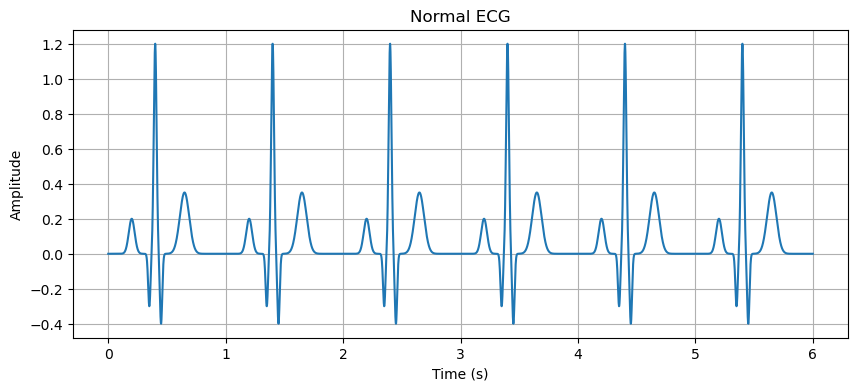

In [4]:
t_normal, normal_signal = generate_normal_ecg(beats=6)
plot_ecg(t_normal, normal_signal, "Normal ECG")

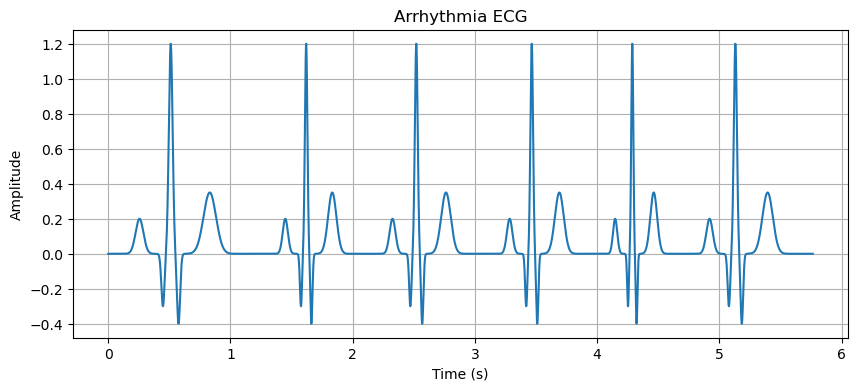

In [5]:
# Generate Arrhythmic ECG
t_arr, arr_signal = generate_arrhythmia_ecg(beats=6)
plot_ecg(t_arr, arr_signal, "Arrhythmia ECG")

In [6]:
# Detect R-peaks and Compute Heart Rate

# Normal ECG
peak_times_normal, peaks_normal = detect_r_peaks(normal_signal, t_normal)
hr_normal = compute_heart_rate(peak_times_normal)

# Arrhythmic ECG
peak_times_arr, peaks_arr = detect_r_peaks(arr_signal, t_arr)
hr_arr = compute_heart_rate(peak_times_arr)

print(f"Normal Heart Rate: {hr_normal:.1f} BPM")
print(f"Arrhythmic Heart Rate: {hr_arr:.1f} BPM")

Normal Heart Rate: 60.0 BPM
Arrhythmic Heart Rate: 64.9 BPM


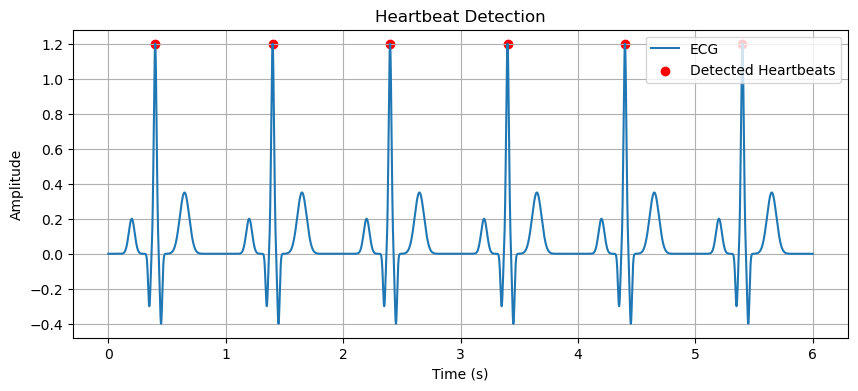

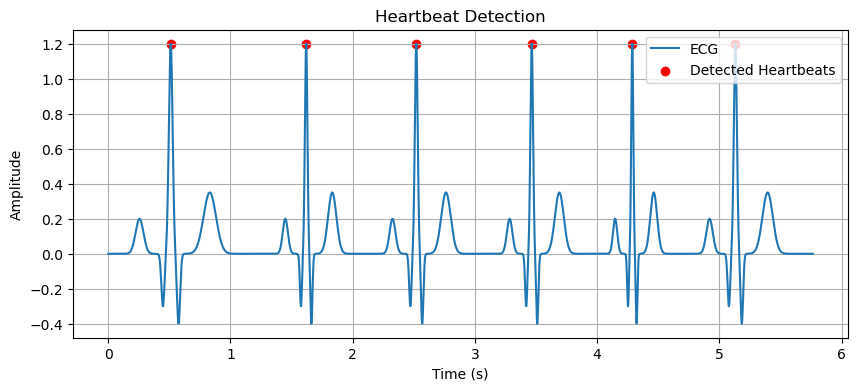

In [7]:
# Plot R-peaks on ECG

# Normal ECG
plot_peaks(t_normal, normal_signal, peak_times_normal, peaks_normal)

# Arrhythmic ECG
plot_peaks(t_arr, arr_signal, peak_times_arr, peaks_arr)

In [8]:
# Heart Rate Variability (HRV) Analysis

def compute_rr_intervals(peak_times):
    """
    Compute RR intervals (time between consecutive R-peaks)
    """
    return np.diff(peak_times)

def hrv_statistics(rr_intervals):
    """
    Compute simple HRV metrics: mean and std of RR intervals
    """
    return np.mean(rr_intervals), np.std(rr_intervals)

# Normal ECG HRV
rr_normal = compute_rr_intervals(peak_times_normal)
mean_rr_normal, std_rr_normal = hrv_statistics(rr_normal)

# Arrhythmic ECG HRV
rr_arr = compute_rr_intervals(peak_times_arr)
mean_rr_arr, std_rr_arr = hrv_statistics(rr_arr)

print(f"Normal RR mean: {mean_rr_normal:.3f}s, std: {std_rr_normal:.3f}s")
print(f"Arrhythmic RR mean: {mean_rr_arr:.3f}s, std: {std_rr_arr:.3f}s")

Normal RR mean: 1.000s, std: 0.000s
Arrhythmic RR mean: 0.924s, std: 0.102s


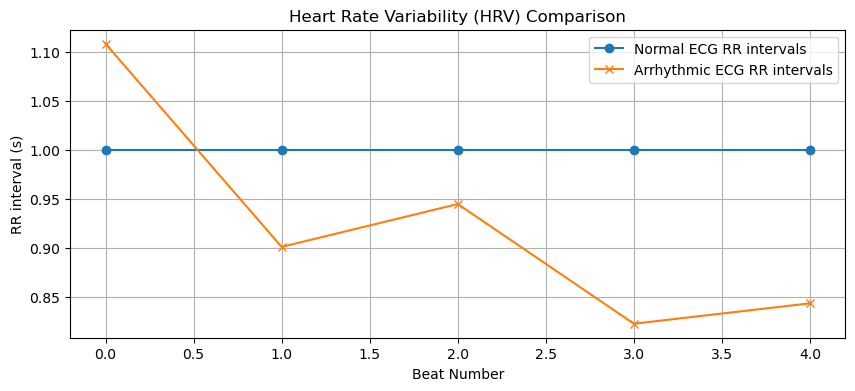

In [9]:
# Plot RR intervals comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(rr_normal, label="Normal ECG RR intervals", marker='o')
plt.plot(rr_arr, label="Arrhythmic ECG RR intervals", marker='x')
plt.xlabel("Beat Number")
plt.ylabel("RR interval (s)")
plt.title("Heart Rate Variability (HRV) Comparison")
plt.legend()
plt.grid()
plt.show()